In [17]:
# Cell 1: Setup and Data Loading for Colab (File Upload Method)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available (for potential future use)
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Load the dataset directly from the current directory
# The file appears in the file explorer as 'all_stocks_5yr.csv'
df = pd.read_csv('all_stocks_5yr.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

GPU Available: []
Dataset loaded successfully!
Shape: (619040, 7)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

First 5 rows:


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [30]:
# Cell 2: Data Preparation (Updated for lowercase columns)
# Focus on Apple (AAPL) - you can change this to any stock
stock_symbol = 'AAPL'
stock_df = df[df['Name'] == stock_symbol].copy()
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df = stock_df.sort_values('date').reset_index(drop=True)

print(f"{stock_symbol} data loaded! Shape: {stock_df.shape}")
print(f"Date range: {stock_df['date'].min()} to {stock_df['date'].max()}")
stock_df.head()

AAPL data loaded! Shape: (1259, 7)
Date range: 2013-02-08 00:00:00 to 2018-02-07 00:00:00


,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [31]:
# Cell 3: Feature Engineering (Updated for lowercase columns)
# Create technical indicators
stock_df['returns'] = stock_df['close'].pct_change()
stock_df['ma_5'] = stock_df['close'].rolling(window=5).mean()
stock_df['ma_10'] = stock_df['close'].rolling(window=10).mean()
stock_df['ma_20'] = stock_df['close'].rolling(window=20).mean()
stock_df['volatility'] = stock_df['returns'].rolling(window=20).std()
stock_df['high_low_ratio'] = stock_df['high'] / stock_df['low']
stock_df['open_close_ratio'] = stock_df['open'] / stock_df['close']


# Drop NaN values
stock_df = stock_df.dropna()

# Prepare features (using lowercase column names)
features = ['open', 'high', 'low', 'volume', 'ma_5', 'ma_10', 'ma_20',
            'volatility', 'high_low_ratio', 'open_close_ratio']
target = 'close'

X = stock_df[features].values
y = stock_df[target].values

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

print(f"Features shape: {X_scaled.shape}")
print(f"Features: {features}")

Features shape: (1239, 10)
Features: ['open', 'high', 'low', 'volume', 'ma_5', 'ma_10', 'ma_20', 'volatility', 'high_low_ratio', 'open_close_ratio']


In [32]:
# Cell 3: Feature Engineering with RSI and MACD (COMPLETE FIX)
print("Creating technical indicators...")

# Define indicator calculation functions
def calculate_rsi(data, window=14):
    """Calculate Relative Strength Index"""
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    # Avoid division by zero
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_macd(data, fast=12, slow=26, signal=9):
    """Calculate MACD line, Signal line, and Histogram"""
    exp1 = data.ewm(span=fast, adjust=False).mean()
    exp2 = data.ewm(span=slow, adjust=False).mean()
    macd_line = exp1 - exp2
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

# Basic technical indicators
stock_df['returns'] = stock_df['close'].pct_change()
stock_df['ma_5'] = stock_df['close'].rolling(window=5).mean()
stock_df['ma_10'] = stock_df['close'].rolling(window=10).mean()
stock_df['ma_20'] = stock_df['close'].rolling(window=20).mean()
stock_df['volatility'] = stock_df['returns'].rolling(window=20).std()
stock_df['high_low_ratio'] = stock_df['high'] / stock_df['low']
stock_df['open_close_ratio'] = stock_df['open'] / stock_df['close']

# Advanced indicators (RSI and MACD)
stock_df['rsi'] = calculate_rsi(stock_df['close'], window=14)
stock_df['macd_line'], stock_df['macd_signal'], stock_df['macd_histogram'] = calculate_macd(stock_df['close'])

# Drop NaN values (caused by rolling calculations)
stock_df = stock_df.dropna()

# Prepare features - now with 14 features
features = ['open', 'high', 'low', 'volume', 'ma_5', 'ma_10', 'ma_20',
            'volatility', 'high_low_ratio', 'open_close_ratio',
            'rsi', 'macd_line', 'macd_signal', 'macd_histogram']
target = 'close'

X = stock_df[features].values
y = stock_df[target].values

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

print(f"✅ Features shape: {X_scaled.shape}")
print(f"📊 Features: {features}")
print(f"📅 Data range: {stock_df['date'].min()} to {stock_df['date'].max()}")
print(f"📈 Total rows after dropping NaN: {len(stock_df)}")

Creating technical indicators...
✅ Features shape: (1219, 14)
📊 Features: ['open', 'high', 'low', 'volume', 'ma_5', 'ma_10', 'ma_20', 'volatility', 'high_low_ratio', 'open_close_ratio', 'rsi', 'macd_line', 'macd_signal', 'macd_histogram']
📅 Data range: 2013-04-09 00:00:00 to 2018-02-07 00:00:00
📈 Total rows after dropping NaN: 1219


In [33]:
# Cell 4: Train-Test Split (Chronological)
split_ratio = 0.8
split_index = int(len(X_scaled) * split_ratio)

X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y_scaled[:split_index], y_scaled[split_index:]

print(f"Training data: {X_train.shape[0]} days")
print(f"Testing data: {X_test.shape[0]} days")
print(f"Training period: {stock_df['date'].iloc[0]} to {stock_df['date'].iloc[split_index-1]}")
print(f"Testing period: {stock_df['date'].iloc[split_index]} to {stock_df['date'].iloc[-1]}")

Training data: 975 days
Testing data: 244 days
Training period: 2013-04-09 00:00:00 to 2017-02-17 00:00:00
Testing period: 2017-02-21 00:00:00 to 2018-02-07 00:00:00


In [34]:
# Cell 5: Train Models
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred_scaled = lr_model.predict(X_test)

print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train.ravel())
rf_pred_scaled = rf_model.predict(X_test)

print("✅ Models trained successfully!")

Training Linear Regression...
Training Random Forest...
✅ Models trained successfully!


In [35]:
# After Cell 5, you could add:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape for LSTM (requires GPU for speed)
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0406 - val_loss: 0.0166
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0151 - val_loss: 0.0041
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0050 - val_loss: 0.0019
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0048 - val_loss: 0.0060
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0027 - val_loss: 9.8915e-04
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - val_loss: 7.3038e-04
Epoch 10/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - l

In [36]:
# Cell 6: Evaluation Functions
def evaluate_model(y_test_scaled, y_pred_scaled, model_name):
    # Inverse transform to actual prices
    y_test_actual = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))
    y_pred_actual = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)

    # Directional Accuracy
    actual_direction = np.sign(y_test_actual[1:] - y_test_actual[:-1])
    pred_direction = np.sign(y_pred_actual[1:] - y_pred_actual[:-1])
    dir_accuracy = np.mean(actual_direction.flatten() == pred_direction.flatten()) * 100

    print(f"\n--- {model_name} Performance ---")
    print(f"RMSE: ${rmse:.2f}")
    print(f"MAE: ${mae:.2f}")
    print(f"Directional Accuracy: {dir_accuracy:.2f}%")

    return y_test_actual, y_pred_actual, rmse, mae, dir_accuracy

# Evaluate both models
lr_results = evaluate_model(y_test, lr_pred_scaled, "Linear Regression")
rf_results = evaluate_model(y_test, rf_pred_scaled, "Random Forest")


--- Linear Regression Performance ---
RMSE: $0.48
MAE: $0.33
Directional Accuracy: 88.48%

--- Random Forest Performance ---
RMSE: $24.45
MAE: $21.40
Directional Accuracy: 59.67%


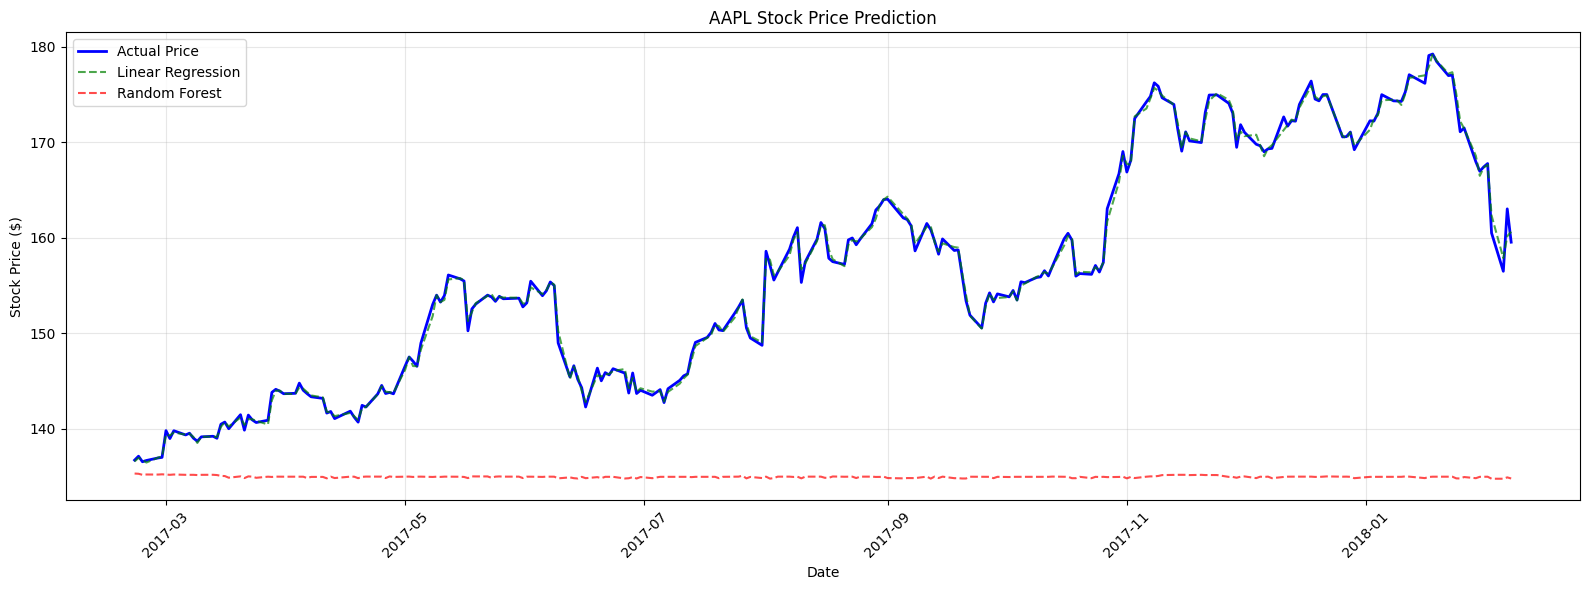

In [37]:
# Cell 7: Visualize Results
plt.figure(figsize=(16, 6))

# Get actual and predicted values from evaluation
y_test_actual_lr = lr_results[0]
y_pred_actual_lr = lr_results[1]
y_test_actual_rf = rf_results[0]
y_pred_actual_rf = rf_results[1]

# Get test dates
test_dates = stock_df['date'].iloc[-len(y_test_actual_lr):]

# Plot
plt.plot(test_dates, y_test_actual_lr, color='blue', label='Actual Price', linewidth=2)
plt.plot(test_dates, y_pred_actual_lr, color='green', label='Linear Regression', linestyle='--', alpha=0.7)
plt.plot(test_dates, y_pred_actual_rf, color='red', label='Random Forest', linestyle='--', alpha=0.7)

plt.title(f'{stock_symbol} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

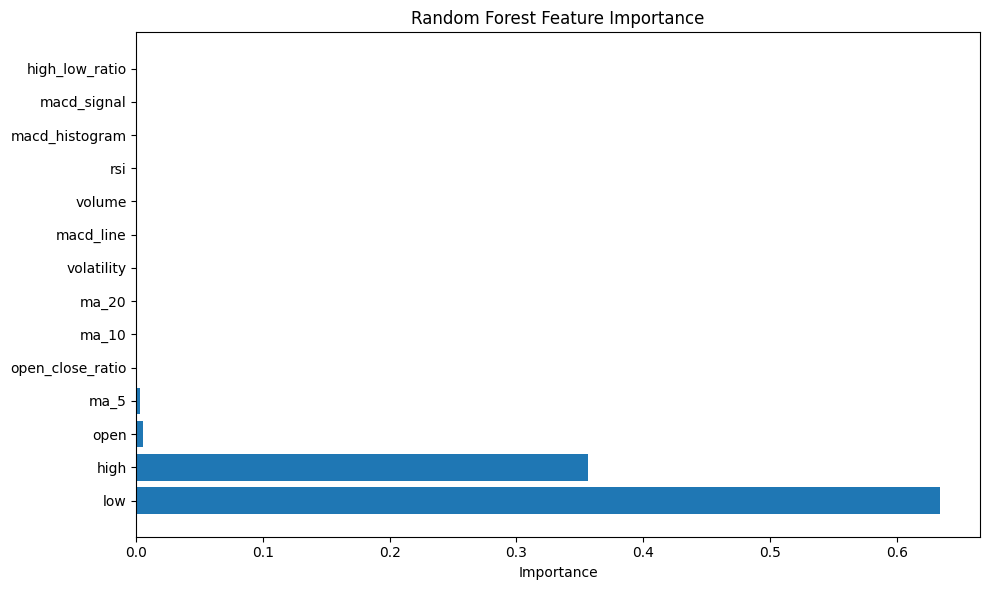


📊 Top 5 Most Important Features:
            Feature  Importance
2               low    0.634037
1              high    0.356338
0              open    0.005725
4              ma_5    0.003055
9  open_close_ratio    0.000303


In [38]:
# Cell 8: Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("\n📊 Top 5 Most Important Features:")
print(feature_importance.head(5))

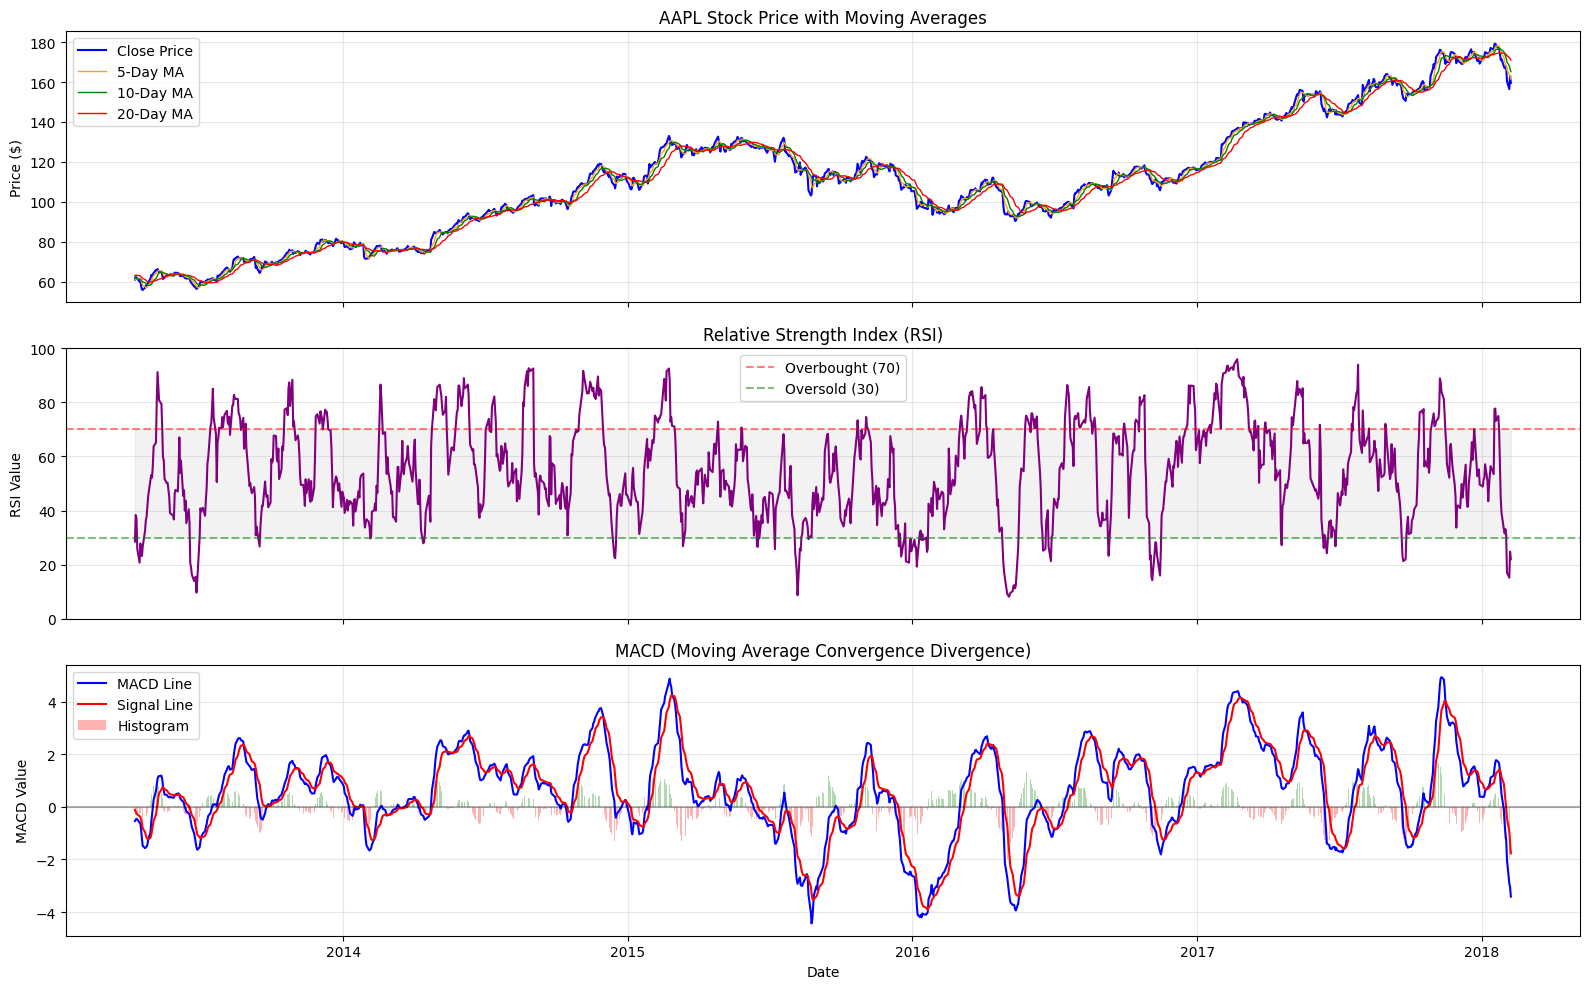

In [39]:
# Cell 8.5: Visualize RSI and MACD Indicators (FIXED)
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Plot 1: Stock Price with Moving Averages (Only the ones we created)
axes[0].plot(stock_df['date'], stock_df['close'], color='blue', label='Close Price', linewidth=1.5)
axes[0].plot(stock_df['date'], stock_df['ma_5'], color='orange', label='5-Day MA', linewidth=1)
axes[0].plot(stock_df['date'], stock_df['ma_10'], color='green', label='10-Day MA', linewidth=1)
axes[0].plot(stock_df['date'], stock_df['ma_20'], color='red', label='20-Day MA', linewidth=1)
axes[0].set_title(f'{stock_symbol} Stock Price with Moving Averages')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: RSI
axes[1].plot(stock_df['date'], stock_df['rsi'], color='purple', linewidth=1.5)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].fill_between(stock_df['date'], 30, 70, alpha=0.1, color='gray')
axes[1].set_title('Relative Strength Index (RSI)')
axes[1].set_ylabel('RSI Value')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: MACD
axes[2].plot(stock_df['date'], stock_df['macd_line'], color='blue', label='MACD Line', linewidth=1.5)
axes[2].plot(stock_df['date'], stock_df['macd_signal'], color='red', label='Signal Line', linewidth=1.5)
# Plot histogram as bars
colors = ['green' if x >= 0 else 'red' for x in stock_df['macd_histogram']]
axes[2].bar(stock_df['date'], stock_df['macd_histogram'], color=colors, alpha=0.3, label='Histogram')
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2].set_title('MACD (Moving Average Convergence Divergence)')
axes[2].set_ylabel('MACD Value')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# Cell 9: Try Different Stocks
# You can change this to test other companies
stocks_to_test = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']

for symbol in stocks_to_test:
    try:
        temp_df = df[df['Name'] == symbol].copy()
        if len(temp_df) > 0:
            print(f"\n✅ {symbol}: {len(temp_df)} days of data available")
        else:
            print(f"\n❌ {symbol}: No data available")
    except:
        print(f"\n❌ {symbol}: Error loading data")


✅ AAPL: 1259 days of data available

✅ GOOGL: 1259 days of data available

✅ MSFT: 1259 days of data available

✅ AMZN: 1259 days of data available

❌ TSLA: No data available


In [41]:
# Cell 10: Save Models
import joblib
from google.colab import files

# Save models and scalers
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

# Download files
files.download('random_forest_model.pkl')
files.download('scaler_X.pkl')
files.download('scaler_y.pkl')

print("✅ Models saved and downloaded successfully!")
print(f"\n📈 Best Model: {'Random Forest' if rf_results[2] < lr_results[2] else 'Linear Regression'}")
print(f"💰 Best RMSE: ${min(rf_results[2], lr_results[2]):.2f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Models saved and downloaded successfully!

📈 Best Model: Linear Regression
💰 Best RMSE: $0.48


In [42]:
# Step 1: Download All Generated Images
import matplotlib.pyplot as plt
from google.colab import files
import os
import io

# Create a folder to store images
!mkdir -p project_images

print("📸 Saving all generated plots...")

# Function to save the current figure
def save_current_plot(filename, folder='project_images'):
    """Save the current matplotlib figure to a file"""
    if plt.get_fignums():
        plt.savefig(f'{folder}/{filename}', dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {filename}")
        plt.close()

# Since we can't automatically capture all previous plots,
# we'll regenerate and save the key ones

print("\n🔄 Regenerating and saving key visualizations...")

# --- Plot 1: Stock Price Prediction Results ---
plt.figure(figsize=(16, 6))
plt.plot(test_dates, y_test_actual_lr, color='blue', label='Actual Price', linewidth=2)
plt.plot(test_dates, y_pred_actual_lr, color='green', label='Linear Regression', linestyle='--', alpha=0.7)
plt.plot(test_dates, y_pred_actual_rf, color='red', label='Random Forest', linestyle='--', alpha=0.7)
plt.title(f'{stock_symbol} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('project_images/1_stock_price_prediction.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 1_stock_price_prediction.png")
plt.close()

# --- Plot 2: Feature Importance ---
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('project_images/2_feature_importance.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 2_feature_importance.png")
plt.close()

# --- Plot 3: Model Performance Comparison ---
models = ['Linear Regression', 'Random Forest']
rmse_scores = [lr_results[2], rf_results[2]]
mae_scores = [lr_results[3], rf_results[3]]
dir_accuracy = [lr_results[4], rf_results[4]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE Plot
axes[0].bar(models, rmse_scores, color=['green', 'red'])
axes[0].set_title('RMSE (Lower is Better)')
axes[0].set_ylabel('Error ($)')
axes[0].grid(True, alpha=0.3)

# MAE Plot
axes[1].bar(models, mae_scores, color=['green', 'red'])
axes[1].set_title('MAE (Lower is Better)')
axes[1].set_ylabel('Error ($)')
axes[1].grid(True, alpha=0.3)

# Directional Accuracy Plot
axes[2].bar(models, dir_accuracy, color=['green', 'red'])
axes[2].set_title('Directional Accuracy (Higher is Better)')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('project_images/3_model_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 3_model_comparison.png")
plt.close()

# --- Plot 4: RSI and MACD Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Stock Price with Moving Averages
axes[0].plot(stock_df['date'], stock_df['close'], color='blue', label='Close Price', linewidth=1.5)
axes[0].plot(stock_df['date'], stock_df['ma_5'], color='orange', label='5-Day MA', linewidth=1)
axes[0].plot(stock_df['date'], stock_df['ma_10'], color='green', label='10-Day MA', linewidth=1)
axes[0].plot(stock_df['date'], stock_df['ma_20'], color='red', label='20-Day MA', linewidth=1)
axes[0].set_title(f'{stock_symbol} Stock Price with Moving Averages')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(stock_df['date'], stock_df['rsi'], color='purple', linewidth=1.5)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].fill_between(stock_df['date'], 30, 70, alpha=0.1, color='gray')
axes[1].set_title('Relative Strength Index (RSI)')
axes[1].set_ylabel('RSI Value')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MACD
axes[2].plot(stock_df['date'], stock_df['macd_line'], color='blue', label='MACD Line', linewidth=1.5)
axes[2].plot(stock_df['date'], stock_df['macd_signal'], color='red', label='Signal Line', linewidth=1.5)
colors = ['green' if x >= 0 else 'red' for x in stock_df['macd_histogram']]
axes[2].bar(stock_df['date'], stock_df['macd_histogram'], color=colors, alpha=0.3, label='Histogram')
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2].set_title('MACD (Moving Average Convergence Divergence)')
axes[2].set_ylabel('MACD Value')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('project_images/4_rsi_macd.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 4_rsi_macd.png")
plt.close()

print("\n" + "="*50)
print("✅ All images saved successfully in 'project_images' folder!")
print("📁 Images saved:")
!ls -la project_images/
print("="*50)

# Create a zip file of all images
!zip -r project_images.zip project_images/
print("\n✅ Created project_images.zip")

# Download the zip file
files.download('project_images.zip')
print("\n✅ Download started! Check your downloads folder.")

📸 Saving all generated plots...

🔄 Regenerating and saving key visualizations...
✅ Saved: 1_stock_price_prediction.png
✅ Saved: 2_feature_importance.png
✅ Saved: 3_model_comparison.png
✅ Saved: 4_rsi_macd.png

✅ All images saved successfully in 'project_images' folder!
📁 Images saved:
total 1644
drwxr-xr-x 2 root root    4096 Aug 20 17:34 .
drwxr-xr-x 1 root root    4096 Aug 20 17:34 ..
-rw-r--r-- 1 root root  357131 Aug 20 17:34 1_stock_price_prediction.png
-rw-r--r-- 1 root root  113073 Aug 20 17:34 2_feature_importance.png
-rw-r--r-- 1 root root  125643 Aug 20 17:34 3_model_comparison.png
-rw-r--r-- 1 root root 1069888 Aug 20 17:34 4_rsi_macd.png
  adding: project_images/ (stored 0%)
  adding: project_images/3_model_comparison.png (deflated 25%)
  adding: project_images/4_rsi_macd.png (deflated 6%)
  adding: project_images/2_feature_importance.png (deflated 33%)
  adding: project_images/1_stock_price_prediction.png (deflated 11%)

✅ Created project_images.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started! Check your downloads folder.
